In [17]:
print("Missing Values:", unsw_train_df.isnull().sum().sum())
print("Duplicate Rows:", unsw_train_df.duplicated().sum())
print("Columns:", unsw_train_df.columns.tolist())

Missing Values: 0
Duplicate Rows: 0
Columns: ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [16]:
unsw_train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  str    
 3   service            82332 non-null  str    
 4   state              82332 non-null  str    
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             82332 non-null

In [15]:
unsw_train_df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [14]:
unsw_train_path = r"C:\Users\Admin\Desktop\Lightweight-IoT-IDS\datasets\UNSW-NB15\UNSW_NB15_training-set.csv"
unsw_test_path = r"C:\Users\Admin\Desktop\Lightweight-IoT-IDS\datasets\UNSW-NB15\UNSW_NB15_testing-set.csv"

unsw_train_df = pd.read_csv(unsw_train_path)
unsw_test_df = pd.read_csv(unsw_test_path)

print("UNSW-NB15 Training Shape:", unsw_train_df.shape)
print("UNSW-NB15 Testing Shape:", unsw_test_df.shape)

UNSW-NB15 Training Shape: (82332, 45)
UNSW-NB15 Testing Shape: (175341, 45)


## UNSW-NB15 Dataset Exploration

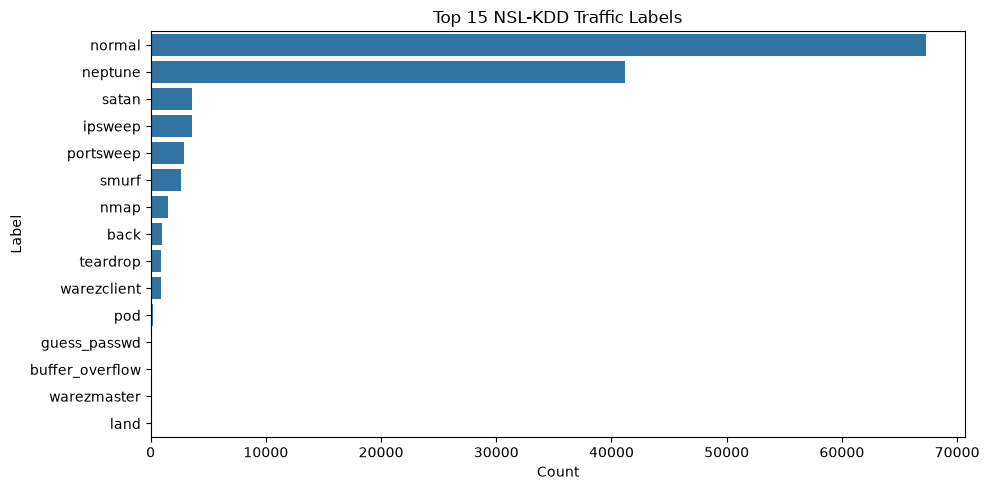

In [13]:
top_labels = train_df['label'].value_counts().head(15)

plt.figure(figsize=(10,5))
sns.barplot(x=top_labels.values, y=top_labels.index)
plt.title('Top 15 NSL-KDD Traffic Labels')
plt.xlabel('Count')
plt.ylabel('Label')
plt.tight_layout()
plt.savefig("../figures/nslkdd_top_15_labels.png", dpi=300)
plt.show()

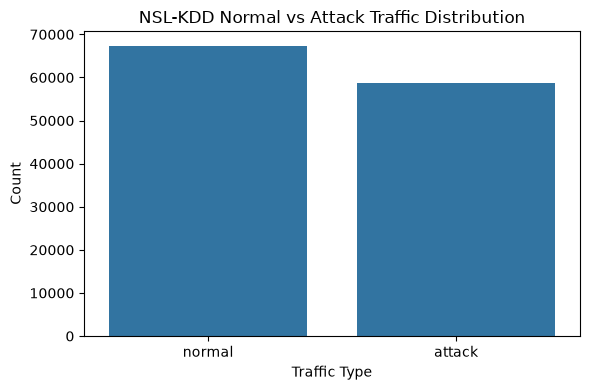

In [12]:
import os

os.makedirs("../figures", exist_ok=True)

plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x='traffic_type')
plt.title('NSL-KDD Normal vs Attack Traffic Distribution')
plt.xlabel('Traffic Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig("../figures/nslkdd_normal_vs_attack.png", dpi=300)
plt.show()

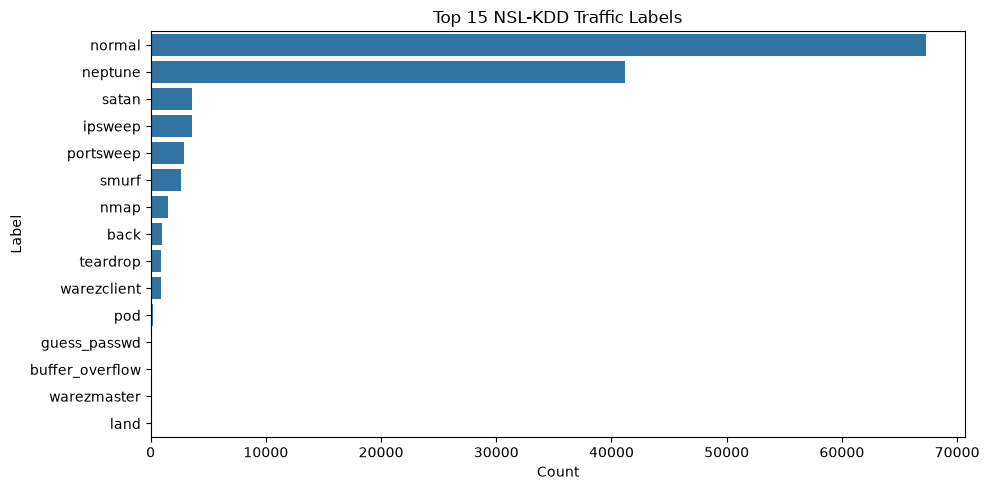

In [11]:
top_labels = train_df['label'].value_counts().head(15)

plt.figure(figsize=(10,5))
sns.barplot(x=top_labels.values, y=top_labels.index)
plt.title('Top 15 NSL-KDD Traffic Labels')
plt.xlabel('Count')
plt.ylabel('Label')
plt.tight_layout()
plt.show()

In [10]:
train_df['label'].value_counts().head(15)

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
Name: count, dtype: int64

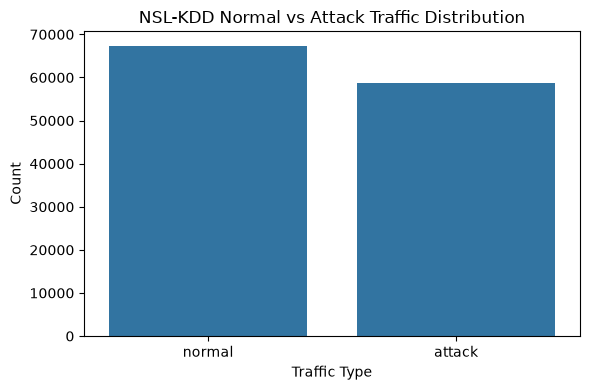

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x='traffic_type')
plt.title('NSL-KDD Normal vs Attack Traffic Distribution')
plt.xlabel('Traffic Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [8]:
train_df['traffic_type'] = train_df['label'].apply(
    lambda x: 'normal' if x == 'normal' else 'attack'
)

train_df['traffic_type'].value_counts()

traffic_type
normal    67343
attack    58630
Name: count, dtype: int64

In [7]:
train_df['traffic_type'] = train_df['label'].apply(
    lambda x: 'normal' if x == 'normal' else 'attack'
)

In [6]:
print("NSL-KDD Training Shape:", train_df.shape)
print("NSL-KDD Testing Shape:", test_df.shape)
print("Total Missing Values:", train_df.isnull().sum().sum())
print("Duplicate Rows:", train_df.duplicated().sum())
print("Number of Attack Labels:", train_df['label'].nunique())

NSL-KDD Training Shape: (125973, 43)
NSL-KDD Testing Shape: (22544, 43)
Total Missing Values: 0
Duplicate Rows: 0
Number of Attack Labels: 23


In [5]:
train_df.isnull().sum().sum()

np.int64(0)

In [4]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

In [3]:
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [2]:
import pandas as pd

# NSL-KDD column names
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins',
    'logged_in','num_compromised','root_shell','su_attempted',
    'num_root','num_file_creations','num_shells','num_access_files',
    'num_outbound_cmds','is_host_login','is_guest_login','count',
    'srv_count','serror_rate','srv_serror_rate','rerror_rate',
    'srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate',
    'label','difficulty'
]

train_path = r"C:\Users\Admin\Desktop\Lightweight-IoT-IDS\datasets\nslkdd\KDDTrain+.txt"
test_path = r"C:\Users\Admin\Desktop\Lightweight-IoT-IDS\datasets\nslkdd\KDDTest+.txt"

train_df = pd.read_csv(train_path, names=columns)
test_df = pd.read_csv(test_path, names=columns)

print("Training Dataset Shape:")
print(train_df.shape)

print("\nTesting Dataset Shape:")
print(test_df.shape)

Training Dataset Shape:
(125973, 43)

Testing Dataset Shape:
(22544, 43)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns